#Name: Santosh mal
#BSCS-V
#Section-F
#CMS: 023-024-0203

In [138]:
import pandas as pd

df = pd.read_csv("Telco Churn EAD.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [139]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

# Part 1 — The Business Problem

#TASK 1
The business wants to understand which customers are likely to leave the company so it can identify customers at risk of churn and take action to retain them. The likely target variable is Churn, because it shows whether a customer has left the service or not.

#Task 2
5 useful predictors of churn:

tenure — Customers who have been with the company for a shorter or longer time may have different churn behavior.

Contract — Customers with different contract types may have different chances of leaving.

MonthlyCharges — Higher or lower monthly charges may affect a customer's decision to stay.

InternetService — The type of internet service a customer uses may be related to churn.

PaymentMethod — Different payment methods may be associated with different customer churn patterns.

2 columns I expect to be useless as predictors:

customerID — It is mainly a unique identifier and does not describe customer behavior.
Churn — It is the target variable itself, so using it as a predictor would cause data leakage.

#TASK 3

Are customers with higher monthly charges more likely to churn?
Does the type of contract affect whether customers stay with or leave the company?

# Part 2 — Exploring the Dataset Structure


1. Check shape and column names

In [140]:
df.shape

(7043, 21)

2. Check data types

In [141]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [142]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


3. See actual rows

In [143]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [144]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2264,7176-WRTNX,Male,0,No,No,70,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),114.95,7711.25,No
4194,2961-VNFKL,Female,0,Yes,No,71,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.95,1801.9,No
2788,2790-XUYMV,Male,0,No,Yes,71,Yes,Yes,Fiber optic,Yes,...,No,No,No,No,One year,Yes,Credit card (automatic),85.45,6028.95,No
472,1304-BCCFO,Male,0,Yes,No,9,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Mailed check,70.05,564.4,No
2494,1596-BBVTG,Male,0,No,No,35,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,No,Credit card (automatic),75.35,2636.05,Yes


4. Check unique values

In [145]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [146]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [147]:
df['PaymentMethod'].unique()

df['gender'].nunique()
df['Contract'].nunique()
df['PaymentMethod'].nunique()
df['PaymentMethod'].unique()


array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

5. Summary statistics

In [148]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


Task 1

The dataset contains 7,043 customers and 21 columns.

Numerical features:

 SeniorCitizen

 tenure

MonthlyCharges

Categorical features:

gender


Partner

Dependents

PhoneService

MultipleLines

InternetService


OnlineSecurity

OnlineBackup

DeviceProtection

TechSupport

StreamingTV

StreamingMovies

Contract

PaperlessBilling

PaymentMethod

Churn

customerID is an identifier rather than a predictive feature. TotalCharges is also stored as an object, even though it represents numerical charge amounts

#task2

customerID — This is an identifier because all 7,043 values are unique, so it does not describe customer behavior.

TotalCharges — Its data type is object, but it represents the total amount charged to a customer, so it should be treated as numerical data.


#Task 3

1. gender

Unique values:

Female, Male

There are no unexpected or inconsistent categories.

2. Contract

Unique values:

Month-to-month, One year, Two year

There are no unexpected or inconsistent categories.

3. PaymentMethod

Unique values:

Electronic check
Mailed check
Bank transfer (automatic)
Credit card (automatic)

There are no obvious unexpected or inconsistent categories.

#Part — Investigating Data Quality

In [149]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [150]:
(df.isnull().sum() / len(df) * 100).round(2)

,0
customerID,0.0
gender,0.0
SeniorCitizen,0.0
Partner,0.0
Dependents,0.0
tenure,0.0
PhoneService,0.0
MultipleLines,0.0
InternetService,0.0
OnlineSecurity,0.0


Task 1 — Missing Values

All columns have 0 missing values, which means the dataset has no missing-value problems according to the missing-value check. The missing-value percentage is also 0% for every column.

Therefore, no missing-value problem requires action because there are no missing entries to remove or fill. The dataset is complete in terms of missing values, so no imputation or row removal is needed for this issue.

Task 2


In [151]:
df.duplicated().sum()

np.int64(0)

In [152]:
df['customerID'].duplicated().sum()

np.int64(0)

Task 2 — Duplicate Rows and Customer IDs

There are 0 duplicate rows in the dataset, meaning no complete row appears more than once.

There are also 0 duplicate customer IDs, meaning every customer ID is unique.

These are different issues: duplicate rows mean the entire record is repeated, while duplicate customer IDs could indicate that the same customer appears in multiple different records. In this dataset, neither issue requires action because both checks returned zero duplicates.

Task 3

In [153]:
df['TotalCharges'].unique()[:20]

array(['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5',
       '1949.4', '301.9', '3046.05', '3487.95', '587.45', '326.8',
       '5681.1', '5036.3', '2686.05', '7895.15', '1022.95', '7382.25',
       '528.35', '1862.9'], dtype=object)

In [154]:
pd.to_numeric(df['TotalCharges'], errors='coerce').isna().sum()


np.int64(11)

### Task 3: Find at least one suspicious/invalid/inconsistently formatted value

A suspicious issue was found in the `TotalCharges` column. Although `TotalCharges` contains numerical values, the column is stored as `object` (text). When I converted the column to numeric values using `pd.to_numeric(..., errors='coerce')`, **11 values were found that could not be converted**.

These values are likely blank or whitespace entries stored as text rather than proper missing values. This explains why the earlier missing-value check showed 0 missing values. The `TotalCharges` column should therefore be cleaned and converted to a numerical datatype before performing numerical analysis.


#Part 4 — Data Cleaning Decisions
Task 1

| Problem                                    | Decision                                     | Method Used                           | Reason                                                                                            |
| ------------------------------------------ | -------------------------------------------- | ------------------------------------- | ------------------------------------------------------------------------------------------------- |
| `TotalCharges` contains non-numeric values | Convert invalid values to missing values     | `pd.to_numeric(..., errors='coerce')` | This safely identifies values that cannot be converted to numbers without deleting valid records. |
| Missing values in `TotalCharges`           | Replace missing values with the median       | `fillna(median)`                      | Median is less affected by extreme values than the mean and allows us to keep the records.        |
| Extra spaces in column values              | Remove unnecessary whitespace                | `str.strip()`                         | Whitespace can create inconsistent categories and affect analysis.                                |
| Duplicate rows                             | Remove exact duplicate records               | `drop_duplicates()`                   | Duplicate records can cause some observations to be counted more than once.                       |
| Incorrect data types                       | Convert columns to appropriate numeric types | `astype()` / `pd.to_numeric()`        | Correct data types are necessary for calculations and machine-learning models.                    |


Task 2

In [155]:
import pandas as pd

cleaned_df = df.copy()

for col in cleaned_df.select_dtypes(include='object').columns:
    cleaned_df[col] = cleaned_df[col].str.strip()

cleaned_df['TotalCharges'] = pd.to_numeric(
    cleaned_df['TotalCharges'],
    errors='coerce'
)

cleaned_df['TotalCharges'] = cleaned_df['TotalCharges'].fillna(
    cleaned_df['TotalCharges'].median()
)

cleaned_df = cleaned_df.drop_duplicates()

cleaned_df['SeniorCitizen'] = cleaned_df['SeniorCitizen'].astype(int)

print("Cleaning completed.")
print("Original shape:", df.shape)
print("Cleaned shape:", cleaned_df.shape)

Cleaning completed.
Original shape: (7043, 21)
Cleaned shape: (7043, 21)


In [156]:
print("Missing values:")
print(cleaned_df.isnull().sum())

print("\nDuplicate rows:")
print(cleaned_df.duplicated().sum())

print("\nTotalCharges data type:")
print(cleaned_df['TotalCharges'].dtype)

print("\nRemaining non-numeric TotalCharges:")
print(pd.to_numeric(cleaned_df['TotalCharges'], errors='coerce').isna().sum())

Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows:
0

TotalCharges data type:
float64

Remaining non-numeric TotalCharges:
0


### Cleaning Verification

The intermediate cleaned dataframe was checked after applying the cleaning decisions. The verification showed that there are no remaining missing values, no duplicate rows, and `TotalCharges` has been successfully converted to the `float64` data type. The check for non-numeric values in `TotalCharges` also returned zero. Therefore, the identified data-quality issues have been resolved in the intermediate cleaned dataframe.


#Part 5 — Univariate EDA

1. Numerical Feature: tenure

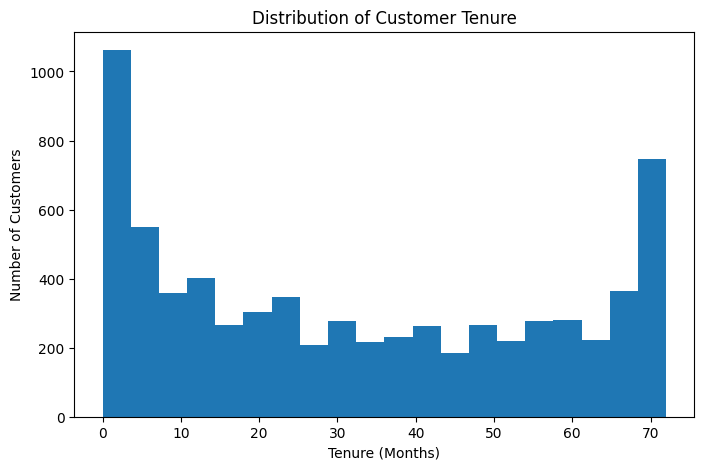

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(cleaned_df['tenure'], bins=20)
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Tenure')
plt.show()

The tenure distribution shows how long customers have stayed with the company. Most customers are concentrated at lower to medium tenure values, while fewer customers have very long-term relationships.


2. Numerical Feature: MonthlyCharges

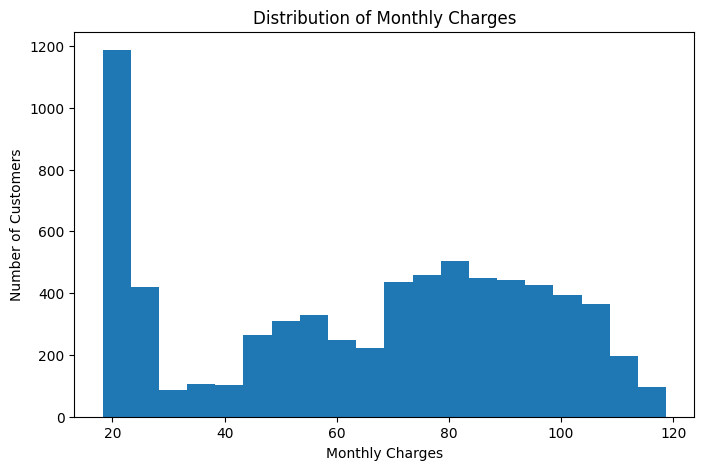

In [158]:
plt.figure(figsize=(8, 5))
plt.hist(cleaned_df['MonthlyCharges'], bins=20)
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.title('Distribution of Monthly Charges')
plt.show()

The MonthlyCharges distribution shows that customers have a wide range of monthly charges. The values are concentrated around the middle range, with fewer customers paying very low or very high monthly charges.


3. Categorical Feature: Contract

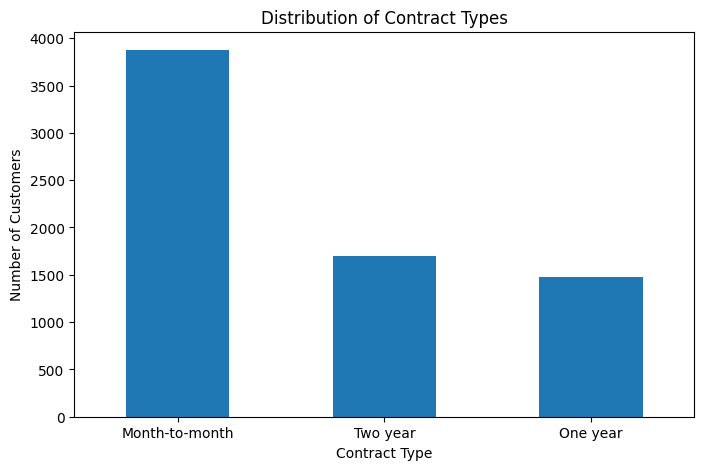

In [159]:
cleaned_df['Contract'].value_counts().plot(kind='bar', figsize=(8, 5))
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.title('Distribution of Contract Types')
plt.xticks(rotation=0)
plt.show()

The chart shows that month-to-month contracts make up a large portion of the customer base. One-year and two-year contracts have fewer customers compared with month-to-month contracts.


4. Categorical Feature: Churn

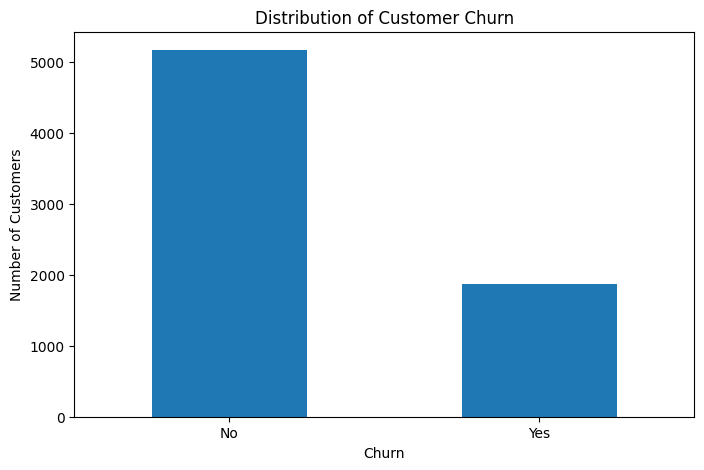

In [160]:
cleaned_df['Churn'].value_counts().plot(kind='bar', figsize=(8, 5))
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.title('Distribution of Customer Churn')
plt.xticks(rotation=0)
plt.show()

The chart shows that the number of customers who stayed with the company is larger than the number who churned. This indicates that the target variable is not evenly distributed between the two classes.


#Task 2 — Outliers and Skewed Distributions

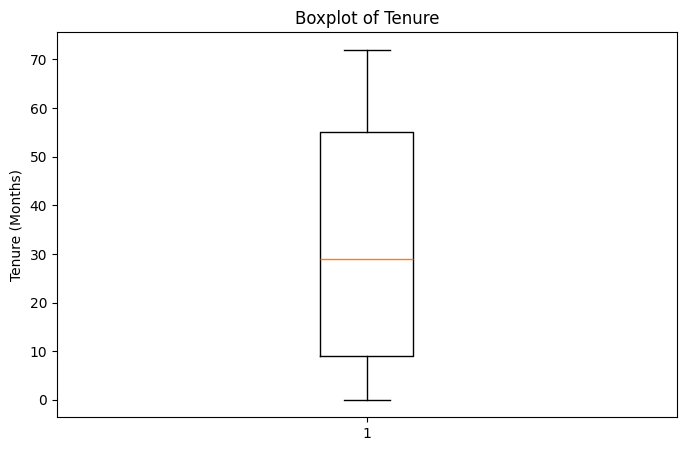

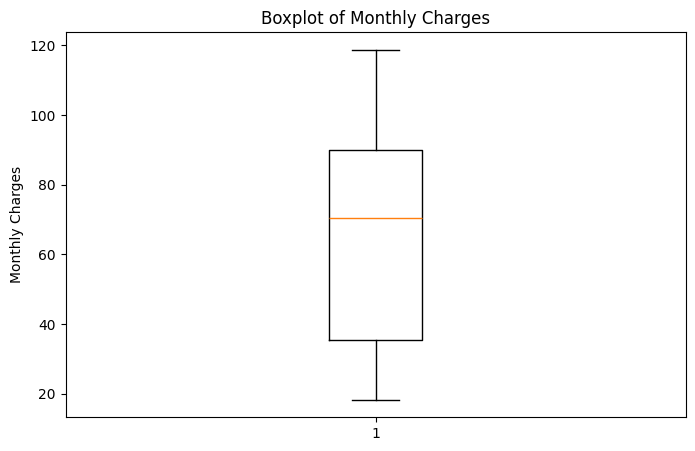

In [161]:
plt.figure(figsize=(8, 5))
plt.boxplot(cleaned_df['tenure'])
plt.ylabel('Tenure (Months)')
plt.title('Boxplot of Tenure')
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(cleaned_df['MonthlyCharges'])
plt.ylabel('Monthly Charges')
plt.title('Boxplot of Monthly Charges')
plt.show()

The numerical features show some variation in their distributions. MonthlyCharges may contain values toward the higher end, while tenure has customers with much longer contracts than the main concentration of customers. These patterns can occur because customers choose different service packages, contract lengths, and combinations of additional services. The distributions should be examined before deciding whether any values need special treatment.


#part 6 — Target Variable Analysis

Task 1 — Number and Percentage of Churned vs. Non-Churned Customers

In [162]:
churn_counts = cleaned_df['Churn'].value_counts()
churn_percentages = cleaned_df['Churn'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Number of Customers': churn_counts,
    'Percentage': churn_percentages.round(2)
})

print(target_summary)

print("Churned customers:", (cleaned_df['Churn'] == 'Yes').sum())
print("Non-churned customers:", (cleaned_df['Churn'] == 'No').sum())

print("\nChurn percentage:",
      round((cleaned_df['Churn'] == 'Yes').mean() * 100, 2), "%")

print("Non-churn percentage:",
      round((cleaned_df['Churn'] == 'No').mean() * 100, 2), "%")

       Number of Customers  Percentage
Churn                                 
No                    5174       73.46
Yes                   1869       26.54
Churned customers: 1869
Non-churned customers: 5174

Churn percentage: 26.54 %
Non-churn percentage: 73.46 %


The `Churn` variable contains both churned and non-churned customers. The target is **imbalanced** because the number of non-churned customers is considerably higher than the number of churned customers.


#Task 2

Class imbalance matters because a classification model may see many more examples of one class than the other during training. As a result, overall accuracy may not fully represent how well the model identifies the less common class, such as customers who churn.


#Part 7 — Bivariate Analysis: Features vs. Churn

Task 1 — Categorical Features vs. Churn

In [163]:
contract_churn = pd.crosstab(
    cleaned_df['Contract'],
    cleaned_df['Churn'],
    normalize='index'
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


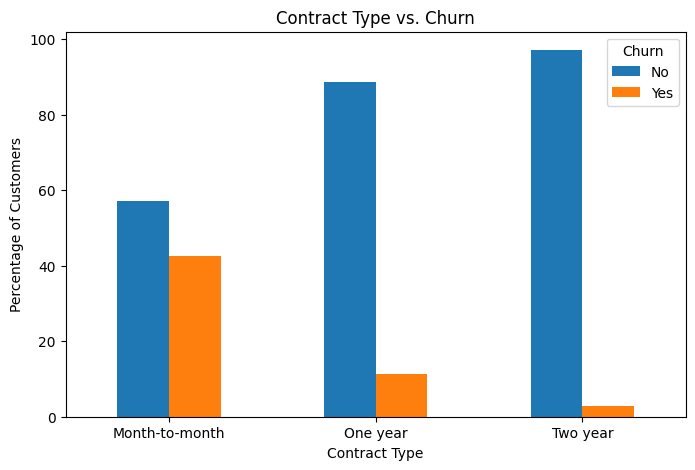

In [164]:
contract_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Contract Type')
plt.ylabel('Percentage of Customers')
plt.title('Contract Type vs. Churn')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Observation:** Churn rates differ across contract types, with month-to-month customers showing a higher proportion of churn compared with customers on longer-term contracts.

**Evidence:** The percentage table and bar chart show a noticeably larger `Yes` proportion for month-to-month contracts than for one-year and two-year contracts.

**Possible Explanation:** Customers with month-to-month contracts have less long-term commitment, so they may have more flexibility to leave the service.


2. InternetService vs. Churn

In [165]:
internet_churn = pd.crosstab(
    cleaned_df['InternetService'],
    cleaned_df['Churn'],
    normalize='index'
) * 100

print(internet_churn.round(2))

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


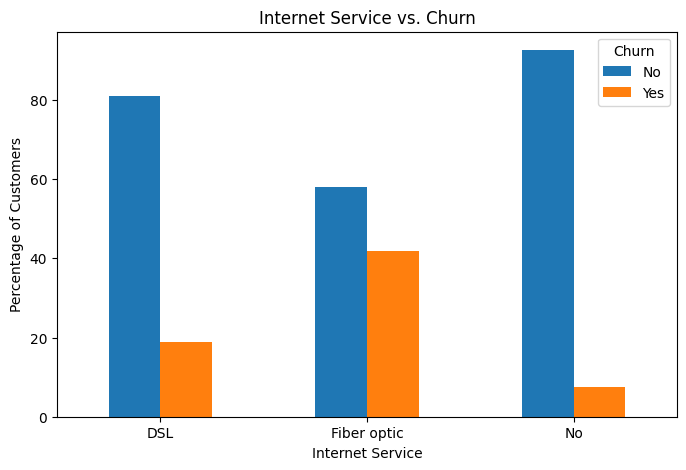

In [166]:
internet_churn.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel('Internet Service')
plt.ylabel('Percentage of Customers')
plt.title('Internet Service vs. Churn')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

**Observation:** Churn rates vary between internet service categories.

**Evidence:** The percentage table and bar chart show different proportions of `Yes` and `No` churn outcomes for DSL, Fiber optic, and customers without internet service.

**Possible Explanation:** Differences may be related to the type of service, pricing, service experience, or the characteristics of customers who choose each internet service.


Task 2 — Numerical Features vs. Churn

1. tenure vs. Churn

<Figure size 800x500 with 0 Axes>

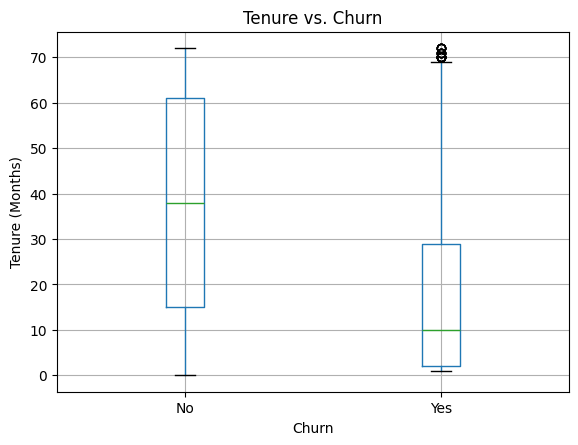

In [167]:
plt.figure(figsize=(8, 5))

cleaned_df.boxplot(
    column='tenure',
    by='Churn'
)

plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.title('Tenure vs. Churn')
plt.suptitle('')
plt.show()

**Observation:** Customers who churn generally have lower tenure than customers who remain with the company.

**Evidence:** The boxplot shows the distribution of tenure for `Churn = Yes` concentrated at lower values compared with `Churn = No`.

**Possible Explanation:** Customers who have been with the company for a shorter period may have less attachment to the service or may be more likely to leave.


2. MonthlyCharges vs. Churn

<Figure size 800x500 with 0 Axes>

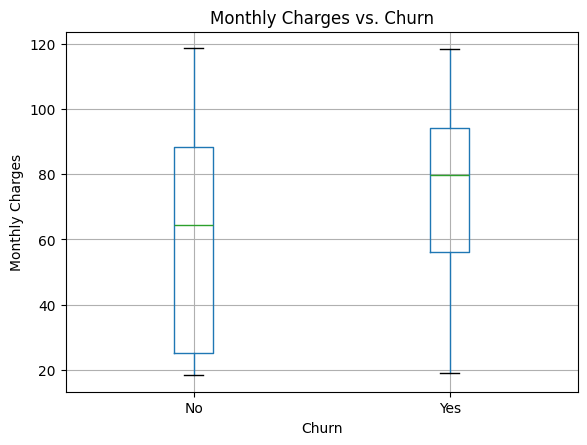

In [168]:
plt.figure(figsize=(8, 5))

cleaned_df.boxplot(
    column='MonthlyCharges',
    by='Churn'
)

plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.title('Monthly Charges vs. Churn')
plt.suptitle('')
plt.show()

**Observation:** Customers who churn tend to have somewhat higher monthly charges than customers who do not churn.

**Evidence:** The boxplot allows the monthly-charge distributions for `Churn = Yes` and `Churn = No` to be compared, showing a higher central tendency for the churned group.

**Possible Explanation:** Higher monthly charges may be associated with more expensive service packages or additional services, which could influence customers' decisions to leave.


#Part 8 — Correlation & Feature Relationships

Task 1 — Compute and Visualize the Correlation Matrix

In [169]:
numerical_features = cleaned_df.select_dtypes(include='number')

correlation_matrix = numerical_features.corr()

print(correlation_matrix.round(2))

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen            1.00    0.02            0.22          0.10
tenure                   0.02    1.00            0.25          0.83
MonthlyCharges           0.22    0.25            1.00          0.65
TotalCharges             0.10    0.83            0.65          1.00


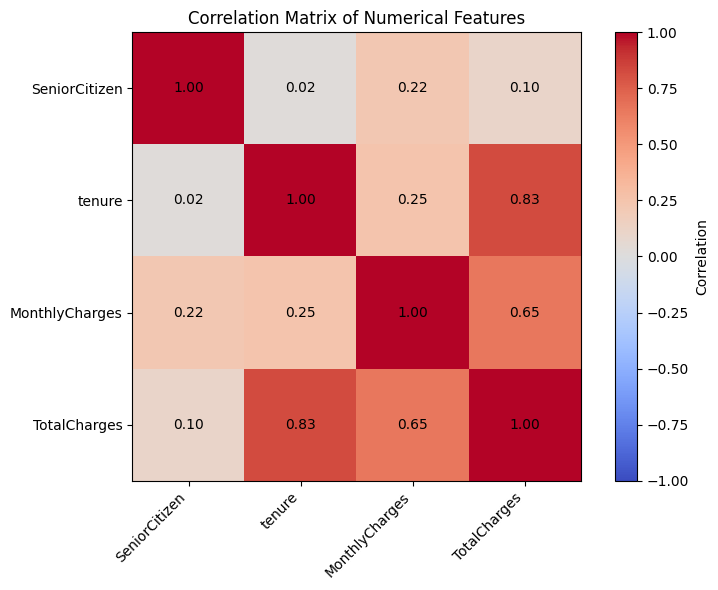

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)

plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(
            j, i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha='center',
            va='center'
        )

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [171]:
corr_pairs = correlation_matrix.where(
    ~correlation_matrix.eq(1)
).stack().sort_values(key=abs, ascending=False)

print(corr_pairs.head(10))

TotalCharges    tenure            0.825464
tenure          TotalCharges      0.825464
TotalCharges    MonthlyCharges    0.650864
MonthlyCharges  TotalCharges      0.650864
tenure          MonthlyCharges    0.247900
MonthlyCharges  tenure            0.247900
                SeniorCitizen     0.220173
SeniorCitizen   MonthlyCharges    0.220173
                TotalCharges      0.102652
TotalCharges    SeniorCitizen     0.102652
dtype: float64


The correlation matrix shows the strength and direction of relationships between the numerical features. The most correlated pairs are the ones with correlation values closest to +1 or -1, while values close to 0 indicate weak linear relationships.


Task 2 — Correlation vs. Causation

Correlation does not mean that one feature causes another; it only shows that the variables are statistically related. Highly correlated features can provide redundant information to a future model, which may make some models harder to interpret and can affect model performance.


#Part 9 — Data Leakage Awareness

Task 1 — Identify Possible Data Leakage and Identifier Columns

In [172]:
print(cleaned_df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [173]:
X = cleaned_df.drop(columns=['customerID', 'Churn'])
y = cleaned_df['Churn']

print("Features:")
print(X.columns.tolist())

Features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


Task 2 — Why Data Leakage Is a Problem

### Task 2 — Explanation

If a column contains information that would only be known after churn has occurred, the model could use information from the future to make its prediction. This would make the model appear more accurate during training or testing than it would be in a real-world situation, leading to unreliable results when predicting actual customers.


#Part 10 — ML-Readiness Checklist

Task 1 — Complete ML-Readiness Table

| Column             | Type             | Role       | Action          | Reason                                                                                              |
| ------------------ | ---------------- | ---------- | --------------- | --------------------------------------------------------------------------------------------------- |
| `customerID`       | Identifier       | Identifier | Remove          | Unique identifier; does not provide useful predictive information.                                  |
| `gender`           | Categorical      | Feature    | Keep            | Customer demographic information that can be used as a feature.                                     |
| `SeniorCitizen`    | Numerical/Binary | Feature    | Keep            | Represents whether the customer is a senior citizen.                                                |
| `Partner`          | Categorical      | Feature    | Keep            | Provides information about the customer's household status.                                         |
| `Dependents`       | Categorical      | Feature    | Keep            | Provides information about whether the customer has dependents.                                     |
| `tenure`           | Numerical        | Feature    | Keep            | Represents how long the customer has been with the company.                                         |
| `PhoneService`     | Categorical      | Feature    | Keep            | Describes whether the customer has phone service.                                                   |
| `MultipleLines`    | Categorical      | Feature    | Keep            | Describes the customer's phone-line service.                                                        |
| `InternetService`  | Categorical      | Feature    | Keep            | Describes the customer's internet service type.                                                     |
| `OnlineSecurity`   | Categorical      | Feature    | Keep            | Describes whether the customer has online security service.                                         |
| `OnlineBackup`     | Categorical      | Feature    | Keep            | Describes whether the customer has online backup service.                                           |
| `DeviceProtection` | Categorical      | Feature    | Keep            | Describes whether the customer has device protection.                                               |
| `TechSupport`      | Categorical      | Feature    | Keep            | Describes whether the customer has technical support.                                               |
| `StreamingTV`      | Categorical      | Feature    | Keep            | Describes whether the customer uses streaming TV service.                                           |
| `StreamingMovies`  | Categorical      | Feature    | Keep            | Describes whether the customer uses streaming movie service.                                        |
| `Contract`         | Categorical      | Feature    | Keep            | Describes the customer's contract type.                                                             |
| `PaperlessBilling` | Categorical      | Feature    | Keep            | Describes the customer's billing preference.                                                        |
| `PaymentMethod`    | Categorical      | Feature    | Keep            | Describes how the customer pays for the service.                                                    |
| `MonthlyCharges`   | Numerical        | Feature    | Keep            | Represents the customer's monthly service charges.                                                  |
| `TotalCharges`     | Numerical        | Feature    | Feature         | Represents the total amount charged to the customer.                                                |
| `Churn`            | Categorical      | Target     | Keep separately | This is the variable the classifier will predict, so it must not be included in the input features. |

**Modeling preparation:** `customerID` should be removed from the feature set, while `Churn` should be kept separately as the target variable. The remaining columns can be used as input features after the required preprocessing/encoding in Lab 3.


In [174]:
X = cleaned_df.drop(columns=['customerID', 'Churn'])
y = cleaned_df['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


#Part 11 — Building the Clean Dataset

Task 1 — Create and Save clean_df

In [175]:
# Part 11 — Task 1

clean_df = cleaned_df.copy()

# Remove identifier column
clean_df = clean_df.drop(columns=['customerID'])

# Save final clean dataset
clean_df.to_csv('clean_churn.csv', index=False)

print("Final dataset shape:", clean_df.shape)
print("\nColumns:")
print(clean_df.columns.tolist())

Final dataset shape: (7043, 20)

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


Task 2 — Final Verification

In [176]:
# Part 11 — Task 2

print("Final clean_df information:")
clean_df.info()

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nData types:")
print(clean_df.dtypes)

Final clean_df information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod 

### Task 2 — Final Verification

The final `clean_df` contains the cleaned dataset with missing values handled, duplicate rows removed, correct data types, and the irrelevant `customerID` identifier removed. Categorical variables and the `Churn` target have been kept in their original form because encoding, train/test splitting, and model training will be performed in Lab 3.


#Part 12 — Key Findings & Final Reflection

# Part 12 — Key Findings & Final Reflection

## Five Important Findings

### Finding 1: Data Quality and `TotalCharges`

**Observation:** `TotalCharges` contained values that were not initially stored as proper numerical values and required cleaning.

**Evidence:** The column was converted to a numerical data type using `pd.to_numeric()`, and missing values were handled using median imputation. After cleaning, its data type was `float64` and no missing values remained.

**Interpretation:** Correctly handling `TotalCharges` was important because numerical analysis and machine learning models require consistent numerical data.

---

### Finding 2: Churn Is an Imbalanced Target

**Observation:** The number of customers who did not churn is considerably higher than the number of customers who churned.

**Evidence:** The Churn distribution showed more `No` values than `Yes` values.

**Interpretation:** The target variable is imbalanced, so accuracy alone may not fully represent how well a future classification model performs, especially on the less common churn class.

---

### Finding 3: Contract Type Is Related to Churn

**Observation:** Customers with different contract types show different churn rates, with month-to-month customers showing a noticeably higher proportion of churn.

**Evidence:** The Contract vs. Churn analysis showed a higher percentage of `Yes` values for month-to-month contracts compared with longer-term contracts.

**Interpretation:** Contract type appears to be an important feature because customer commitment and contract structure may be associated with whether a customer leaves the company.

---

### Finding 4: Tenure Is Related to Churn

**Observation:** Customers who churn generally have lower tenure than customers who remain.

**Evidence:** The tenure vs. Churn boxplot showed that churned customers tend to have lower tenure values.

**Interpretation:** Newer customers may be more likely to leave, while customers who have stayed longer may have a stronger relationship with the company.

---

### Finding 5: Numerical Features Have Relationships With Each Other

**Observation:** Some numerical variables, particularly `tenure` and `TotalCharges`, show a strong positive relationship.

**Evidence:** The correlation matrix showed that some numerical feature pairs had substantially higher correlation values than others.

**Interpretation:** Highly correlated features may contain overlapping information. This should be considered during future modeling because redundant features can affect some models and make interpretation more difficult.

---

# Final Reflection

### 1. What was the most important data-quality issue you found?

The most important issue was the inconsistent data type of `TotalCharges`. Some values could not initially be treated as numerical values, so the column had to be converted and its resulting missing values handled before analysis and modeling.

### 2. What was the most interesting pattern you discovered?

The most interesting pattern was the relationship between contract type and churn. Month-to-month customers showed a noticeably higher churn rate than customers with longer-term contracts.

### 3. Which feature seems most useful for predicting churn?

Based on the EDA, **Contract** appears to be one of the most useful features because the churn rate differs substantially across contract types. `tenure` also appears informative because churned customers generally have shorter customer histories.

### 4. Which feature should probably not be used, and why?

`customerID` should not be used as a predictive feature because it is only an identifier. It does not represent a meaningful customer characteristic and could introduce irrelevant information into the model.

### 5. What preprocessing will be required before ML modeling?

Before modeling, categorical features will need to be converted into numerical representations through encoding. The dataset will also need to be separated into input features and the `Churn` target, and the data should then be split into training and testing sets. Any additional preprocessing should be fitted using the training data to avoid data leakage.

### 6. What would you do next if you had another 3 hours?

With another three hours, I would prepare the data for machine learning, encode the categorical variables, split the dataset into training and testing sets, and train a baseline classification model. I would then evaluate it using appropriate classification metrics and compare its performance across the churn and non-churn classes.


#Bonus tasks

1. Additional Meaningful Visualization

Churn                           Churn Rate (%)
Contract       InternetService                
Month-to-month DSL                       32.22
               Fiber optic               54.61
               No                        18.89
One year       DSL                        9.30
               Fiber optic               19.29
               No                         2.47
Two year       DSL                        1.91
               Fiber optic                7.23
               No                         0.78


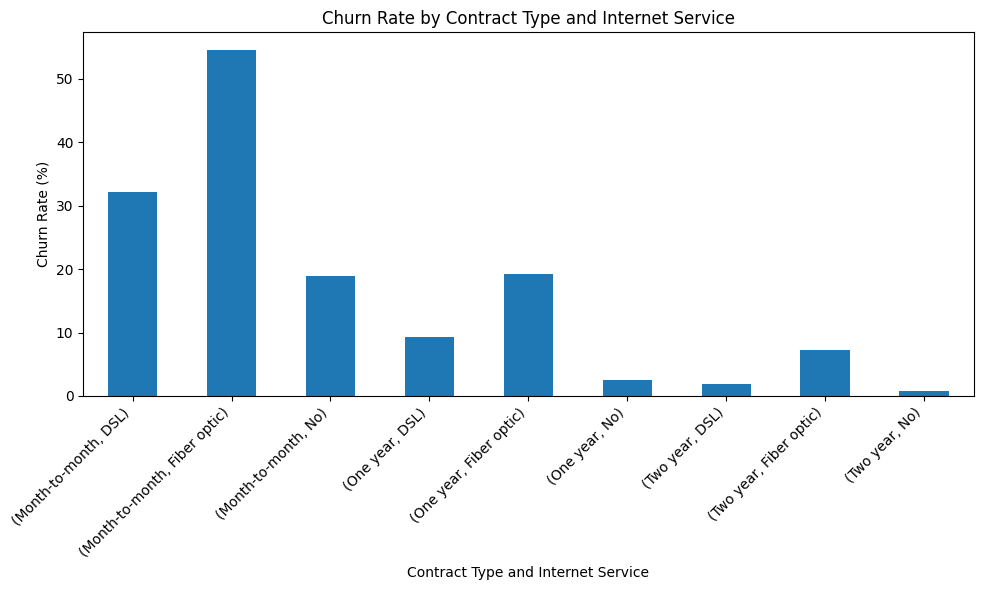

In [177]:
# Additional Analysis 1 — Churn Rate by Contract and Internet Service

churn_combo = pd.crosstab(
    [clean_df['Contract'], clean_df['InternetService']],
    clean_df['Churn'],
    normalize='index'
) * 100

churn_combo = churn_combo[['Yes']].rename(columns={'Yes': 'Churn Rate (%)'})

print(churn_combo.round(2))

churn_combo.plot(
    kind='bar',
    figsize=(10, 6),
    legend=False
)

plt.xlabel('Contract Type and Internet Service')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type and Internet Service')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The visualization shows that churn rates vary when contract type and internet service are considered together. This provides more detailed information than examining either feature individually and helps identify customer segments with different levels of churn.


In [178]:
# Additional Analysis 2 — Senior Citizens with Month-to-Month Contracts

subgroup = clean_df[
    (clean_df['SeniorCitizen'] == 1) &
    (clean_df['Contract'] == 'Month-to-month')
]

print("Number of customers:", len(subgroup))
print("\nChurn distribution:")
print(subgroup['Churn'].value_counts())

print("\nChurn rate:")
print(round((subgroup['Churn'] == 'Yes').mean() * 100, 2), "%")

Number of customers: 807

Churn distribution:
Churn
Yes    441
No     366
Name: count, dtype: int64

Churn rate:
54.65 %


Senior citizens with month-to-month contracts form a specific customer subgroup that can be examined separately. Their churn rate can reveal whether this combination of characteristics is associated with a noticeably different churn pattern compared with the overall customer population.


In [179]:
# Additional Analysis 3 — Churn Rate Across Multiple Segments

multi_segment_churn = pd.crosstab(
    [
        clean_df['Contract'],
        clean_df['InternetService'],
        clean_df['PaymentMethod']
    ],
    clean_df['Churn'],
    normalize='index'
) * 100

multi_segment_churn = multi_segment_churn.rename(
    columns={'Yes': 'Churn Rate (%)', 'No': 'Non-Churn Rate (%)'}
)

print(multi_segment_churn.round(2))

Churn                                                     Non-Churn Rate (%)  \
Contract       InternetService PaymentMethod                                   
Month-to-month DSL             Bank transfer (automatic)               80.20   
                               Credit card (automatic)                 72.97   
                               Electronic check                        59.49   
                               Mailed check                            69.21   
               Fiber optic     Bank transfer (automatic)               54.43   
                               Credit card (automatic)                 58.36   
                               Electronic check                        39.63   
                               Mailed check                            49.25   
               No              Bank transfer (automatic)               80.00   
                               Credit card (automatic)                 90.77   
                               Electroni

In [180]:
print(
    multi_segment_churn
    .sort_values('Churn Rate (%)', ascending=False)
    .head(10)
    .round(2)
)

Churn                                                     Non-Churn Rate (%)  \
Contract       InternetService PaymentMethod                                   
Month-to-month Fiber optic     Electronic check                        39.63   
                               Mailed check                            49.25   
                               Bank transfer (automatic)               54.43   
                               Credit card (automatic)                 58.36   
               DSL             Electronic check                        59.49   
                               Mailed check                            69.21   
                               Credit card (automatic)                 72.97   
One year       Fiber optic     Electronic check                        73.98   
Month-to-month No              Mailed check                            79.38   
                               Bank transfer (automatic)               80.00   

Churn                                  

Churn rates differ across combinations of contract type, internet service, and payment method. Examining multiple segments together can reveal patterns that may not be visible when analyzing each feature separately.


In [181]:

# Additional Analysis 4 — Feature Engineering Opportunity

clean_df['AverageMonthlySpend'] = (
    clean_df['TotalCharges'] / clean_df['tenure'].replace(0, 1)
)

print(clean_df[['TotalCharges', 'tenure', 'AverageMonthlySpend']].head())

   TotalCharges  tenure  AverageMonthlySpend
0         29.85       1            29.850000
1       1889.50      34            55.573529
2        108.15       2            54.075000
3       1840.75      45            40.905556
4        151.65       2            75.825000


### Possible Source of Bias

One possible source of bias is that the dataset may not represent all types of customers equally. For example, some customer groups may be overrepresented while others may have relatively few observations, which could cause a machine-learning model to learn patterns that work better for the larger groups than for underrepresented groups.


In [182]:
print("Shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(clean_df.duplicated().sum())

print("\nData types:")
print(clean_df.dtypes)

print("\nColumns:")
print(clean_df.columns.tolist())


Shape: (7043, 21)

Missing values:
0

Duplicate rows:
22

Data types:
gender                  object
SeniorCitizen            int64
Partner                 object
Dependents              object
tenure                   int64
PhoneService            object
MultipleLines           object
InternetService         object
OnlineSecurity          object
OnlineBackup            object
DeviceProtection        object
TechSupport             object
StreamingTV             object
StreamingMovies         object
Contract                object
PaperlessBilling        object
PaymentMethod           object
MonthlyCharges         float64
TotalCharges           float64
Churn                   object
AverageMonthlySpend    float64
dtype: object

Columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'Paym

In [183]:
clean_df.to_csv('clean_churn.csv', index=False)
print("clean_churn.csv created successfully!")

clean_churn.csv created successfully!
